# 24-Hour Cumulative Session Liquidity & Volatility Heatmap
*(Explicit Period Mapping: Day / Week / Month Aggregated 24-Hour Matrix)*

### Key Features
1. **Explicit Period Configuration (`PERIODS` Dictionary + `N_TRADING_DAYS = PERIODS[PERIOD]`)**:
   - `PERIOD = "day"` $\rightarrow$ `N_TRADING_DAYS = 1`: Most recent complete trading day (24 Hours).
   - `PERIOD = "week"` $\rightarrow$ `N_TRADING_DAYS = 5`: Cumulative average over the last 5 complete trading days (Mon–Fri).
   - `PERIOD = "month"` $\rightarrow$ `N_TRADING_DAYS = 20`: Cumulative average over the last 20 complete trading days (~4 Trading Weeks).
2. **24-Hour Aggregated Matrix (00:00 – 23:00 UTC)**: Aggregates tick-level spreads and H1 price ranges into a single 24-hour profile over the selected period.
3. **Per-Symbol Robust Normalization (P10-P85) + Minimum Span Anchoring (`min_span_pct=0.20`)**:
   - Prevents instruments with near-constant spreads (e.g. WTI 3.49 vs 3.53 cents) from over-amplifying tiny noise into dramatic color shifts.
   - Enforces an effective span anchor (min 20% of median), preserving flat/uniform colors for stable instruments while retaining full 0..1 color range for instruments with real intraday shifts.
4. **Zero-Value Masking**: Market-closed or zero-spread hours are shaded in **dark grey (#2A2A2A)** with muted text, preventing false "brightest/tightest" highlight.
5. **Dynamic Text Contrast**: Text color (black vs. white) is calculated automatically from the cell's RGB luminance for 100% legibility across all colormaps.

### Three Cumulative Heatmaps
1. **Spread** `YlOrRd` — yellow = tightest average spread, red = widest
2. **Volatility** `viridis` — dark = calm, bright = high price movement  
3. **Efficiency** `RdYlGn` — green = best execution hours (high vol / low spread)

### Sessions (UTC)
| Session | Hours |
|---|---|
| Asian | 00-12 |
| London | 10-19 |
| **London/NY Overlap** | **15-19** |
| New York | 15-24 |
| **Rollover** | **00-01** |


In [79]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from datetime import datetime, timedelta, UTC

plt.style.use('dark_background')
print("Imports OK")


Imports OK


In [80]:
if not mt5.initialize():
    raise RuntimeError(f"MT5 init failed: {mt5.last_error()}")
info = mt5.terminal_info()
print(f"Connected: {info.name} ({info.company}) | Build {mt5.version()[1]}")


Connected: RoboForex MT5 Terminal (RoboForex Ltd) | Build 6061


In [87]:
# Period Options Dictionary (Maps period key to trading days count)
PERIODS = {
    "day":   1,
    "week":  5,
    "month": 20
}

# User Selection: Set to "day", "week", or "month"
PERIOD = "week"

# Explicit Binding & Validation
if PERIOD not in PERIODS:
    raise KeyError(f"Invalid PERIOD '{PERIOD}'. Must be one of: {list(PERIODS.keys())}")
N_TRADING_DAYS = PERIODS[PERIOD]

SYMBOLS = ["EURUSD", "GBPUSD","AUDUSD", "NZDUSD", "USDCAD", "USDJPY", "WTI", "XAUUSD", ".US500Cash", ".USTECHCash"]

HOUR_LABELS = [f"{h:02d}:00" for h in range(24)]
SESSION_BANDS = [
    (0,  12,  "Asian",    "#00E676"),
    (10,  19, "London",   "#00B0FF"),
    (15, 24, "New York", "#FF9100"),
    (0, 1, "Rollover", "#FF1744"),
]
print(f"Period set to: '{PERIOD.upper()}' ({N_TRADING_DAYS} trading day(s)) | Symbols: {SYMBOLS}")


Period set to: 'WEEK' (5 trading day(s)) | Symbols: ['EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDJPY', 'WTI', 'XAUUSD', '.US500Cash', '.USTECHCash']


In [88]:
def get_trading_days(n_days=5):
    """Return list of complete weekday date objects (oldest to newest)."""
    now = datetime.now()
    day = now.date()
    if day == now.date() and now.hour < 3:
        day -= timedelta(days=1)

    days = []
    curr = day
    while len(days) < n_days:
        if curr.weekday() < 5:
            days.append(curr)
        curr -= timedelta(days=1)
    days.reverse()
    return days

def row_normalize_robust(data, lo_pct=10, hi_pct=85, min_span_pct=0.20):
    """
    Per-row robust percentile scaling with Minimum Span Anchoring.
    Prevents near-constant symbols (e.g. WTI 3.49 vs 3.53) from over-amplifying noise into full color swings.
    """
    data_arr = np.asarray(data, dtype=float)
    normed = np.zeros_like(data_arr, dtype=float)
    for i in range(data_arr.shape[0]):
        row = data_arr[i]
        nonzero = row[row > 0]
        if len(nonzero) == 0:
            continue
        lo = np.percentile(nonzero, lo_pct)
        hi = np.percentile(row, hi_pct)
        med = np.median(nonzero)

        span = hi - lo
        min_span = med * min_span_pct
        effective_span = max(span, min_span)

        clipped = np.clip(row, lo, hi)
        norm_row = (clipped - lo) / effective_span if effective_span > 0 else 0.5
        normed[i] = np.clip(norm_row, 0.0, 1.0)
    return normed

def add_session_bands(ax):
    for start, end, label, color in SESSION_BANDS:
        rect = Rectangle((start - 0.5, -0.75), end - start, 0.22,
                          facecolor=color, alpha=0.85, clip_on=False)
        ax.add_patch(rect)
        ax.text((start + end) / 2 - 0.5, -0.64, label,
                ha="center", va="center", color="black",
                fontsize=7.5, fontweight="bold", clip_on=False)

def draw_heatmap(raw, norm, syms, cmap_name, cbar_lo, cbar_hi, title, fmt_fn, overlap=False):
    n = len(syms)
    fig, ax = plt.subplots(figsize=(18, max(5, n * 1.3)), dpi=150)

    cmap = plt.colormaps.get_cmap(cmap_name).copy()
    cmap.set_bad(color='#2A2A2A')

    norm_masked = np.ma.masked_where(raw <= 0, norm)
    im = ax.imshow(norm_masked, cmap=cmap, aspect="auto", vmin=0, vmax=1)

    cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.025)
    cbar.set_ticks([0, 0.5, 1.0])
    cbar.set_ticklabels([cbar_lo, "Mid (per sym)", cbar_hi], color="#CCCCCC", fontsize=8)
    cbar.set_label("Relative scale — per-symbol, P10-P85 & min-span anchor", rotation=270, labelpad=20, color="#CCCCCC", fontsize=8)

    ax.set_xticks(range(24))
    ax.set_xticklabels(HOUR_LABELS, rotation=45, ha="right", fontsize=9, color="#CCCCCC")
    ax.set_yticks(range(n))
    ax.set_yticklabels(syms, fontsize=11, fontweight="bold", color="#E0E0E0")

    for i in range(n):
        for j in range(24):
            val = raw[i, j]
            if val <= 0:
                txt = "0.00"
                tc = "#666666"
            else:
                txt = fmt_fn(val)
                r, g, b, _ = cmap(norm[i, j])
                lum = 0.299 * r + 0.587 * g + 0.114 * b
                tc = "black" if lum > 0.45 else "white"
            ax.text(j, i, txt, ha="center", va="center", color=tc, fontsize=7.5, fontweight="bold" if tc=="black" else "normal")

    ax.set_title(title, fontsize=13, pad=28, fontweight="bold", color="#E0E0E0")
    ax.set_xlabel("Hour of Day (UTC)", fontsize=11, labelpad=10, color="#CCCCCC")
    add_session_bands(ax)

    if overlap:
        ax.axvspan(12.5, 16.5, color="#FFEA00", alpha=0.07, zorder=0)
        ax.text(16.5, -0.64, "Peak Overlap (London+NY)",
                ha="center", va="center", color="#FFEA00",
                fontsize=8, fontweight="bold", clip_on=False)
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")


Helper functions defined.


In [89]:
unit_map = {}

def build_24h_cumulative_matrices(symbols, n_days=5):
    days = get_trading_days(n_days)
    range_str = f"{days[0]}" if len(days) == 1 else f"{days[0]} to {days[-1]}"
    print(f"Target period '{PERIOD.upper()}': {len(days)} trading day(s) ({range_str})")

    date_from = datetime.combine(days[0], datetime.min.time(), tzinfo=UTC)
    date_to = datetime.combine(days[-1], datetime.max.time().replace(microsecond=0), tzinfo=UTC)

    sp, vol, vm = {}, {}, {}

    for sym in symbols:
        info = mt5.symbol_info(sym)
        if info is None:
            print(f"  {sym}: not found, skipping.")
            continue
        point = info.point if info.point > 0 else 0.00001
        digits = info.digits
        if digits in [3, 5]:
            unit, scale = "pips", 10.0 * point
        elif digits == 2 and any(k in sym for k in ("USD", "WTI", "BRENT")):
            unit, scale = "cents", point
        else:
            unit, scale = "pts", point
        label = f"{sym} ({unit})"
        unit_map[sym] = (unit, scale, label)

        # Ticks -> 24h mean spread across period
        ticks = mt5.copy_ticks_range(sym, date_from, date_to, mt5.COPY_TICKS_ALL)
        if ticks is not None and len(ticks) > 0:
            dt = pd.DataFrame(ticks)
            dt["hour"] = pd.to_datetime(dt["time_msc"], unit="ms", utc=True).dt.hour
            dt["sp"]   = (dt["ask"] - dt["bid"]) / scale
            sp[label]  = dt.groupby("hour")["sp"].mean().reindex(range(24)).fillna(0)
        else:
            sp[label]  = pd.Series(0, index=range(24))

        # H1 bars -> 24h mean volatility & tick volume across period
        rates = mt5.copy_rates_range(sym, mt5.TIMEFRAME_H1, date_from, date_to)
        if rates is not None and len(rates) > 0:
            dr = pd.DataFrame(rates)
            dr["hour"] = pd.to_datetime(dr["time"], unit="s", utc=True).dt.hour
            dr["rng"]  = (dr["high"] - dr["low"]) / scale
            vol[label] = dr.groupby("hour")["rng"].mean().reindex(range(24)).fillna(0)
            vm[label]  = dr.groupby("hour")["tick_volume"].mean().reindex(range(24)).fillna(0)
        else:
            vol[label] = pd.Series(0, index=range(24))
            vm[label]  = pd.Series(0, index=range(24))

    df_sp  = pd.DataFrame(sp)
    df_v   = pd.DataFrame(vol)
    df_vm  = pd.DataFrame(vm)

    print(f"Built cumulative 24h matrices for {len(df_sp.columns)} symbols across {len(days)} trading day(s).")
    return days, df_sp, df_v, df_vm

days, df_spread, df_vol, df_volm = build_24h_cumulative_matrices(SYMBOLS, N_TRADING_DAYS)


Target period 'WEEK': 5 trading day(s) (2026-07-27 to 2026-07-31)
Built cumulative 24h matrices for 10 symbols across 5 trading day(s).


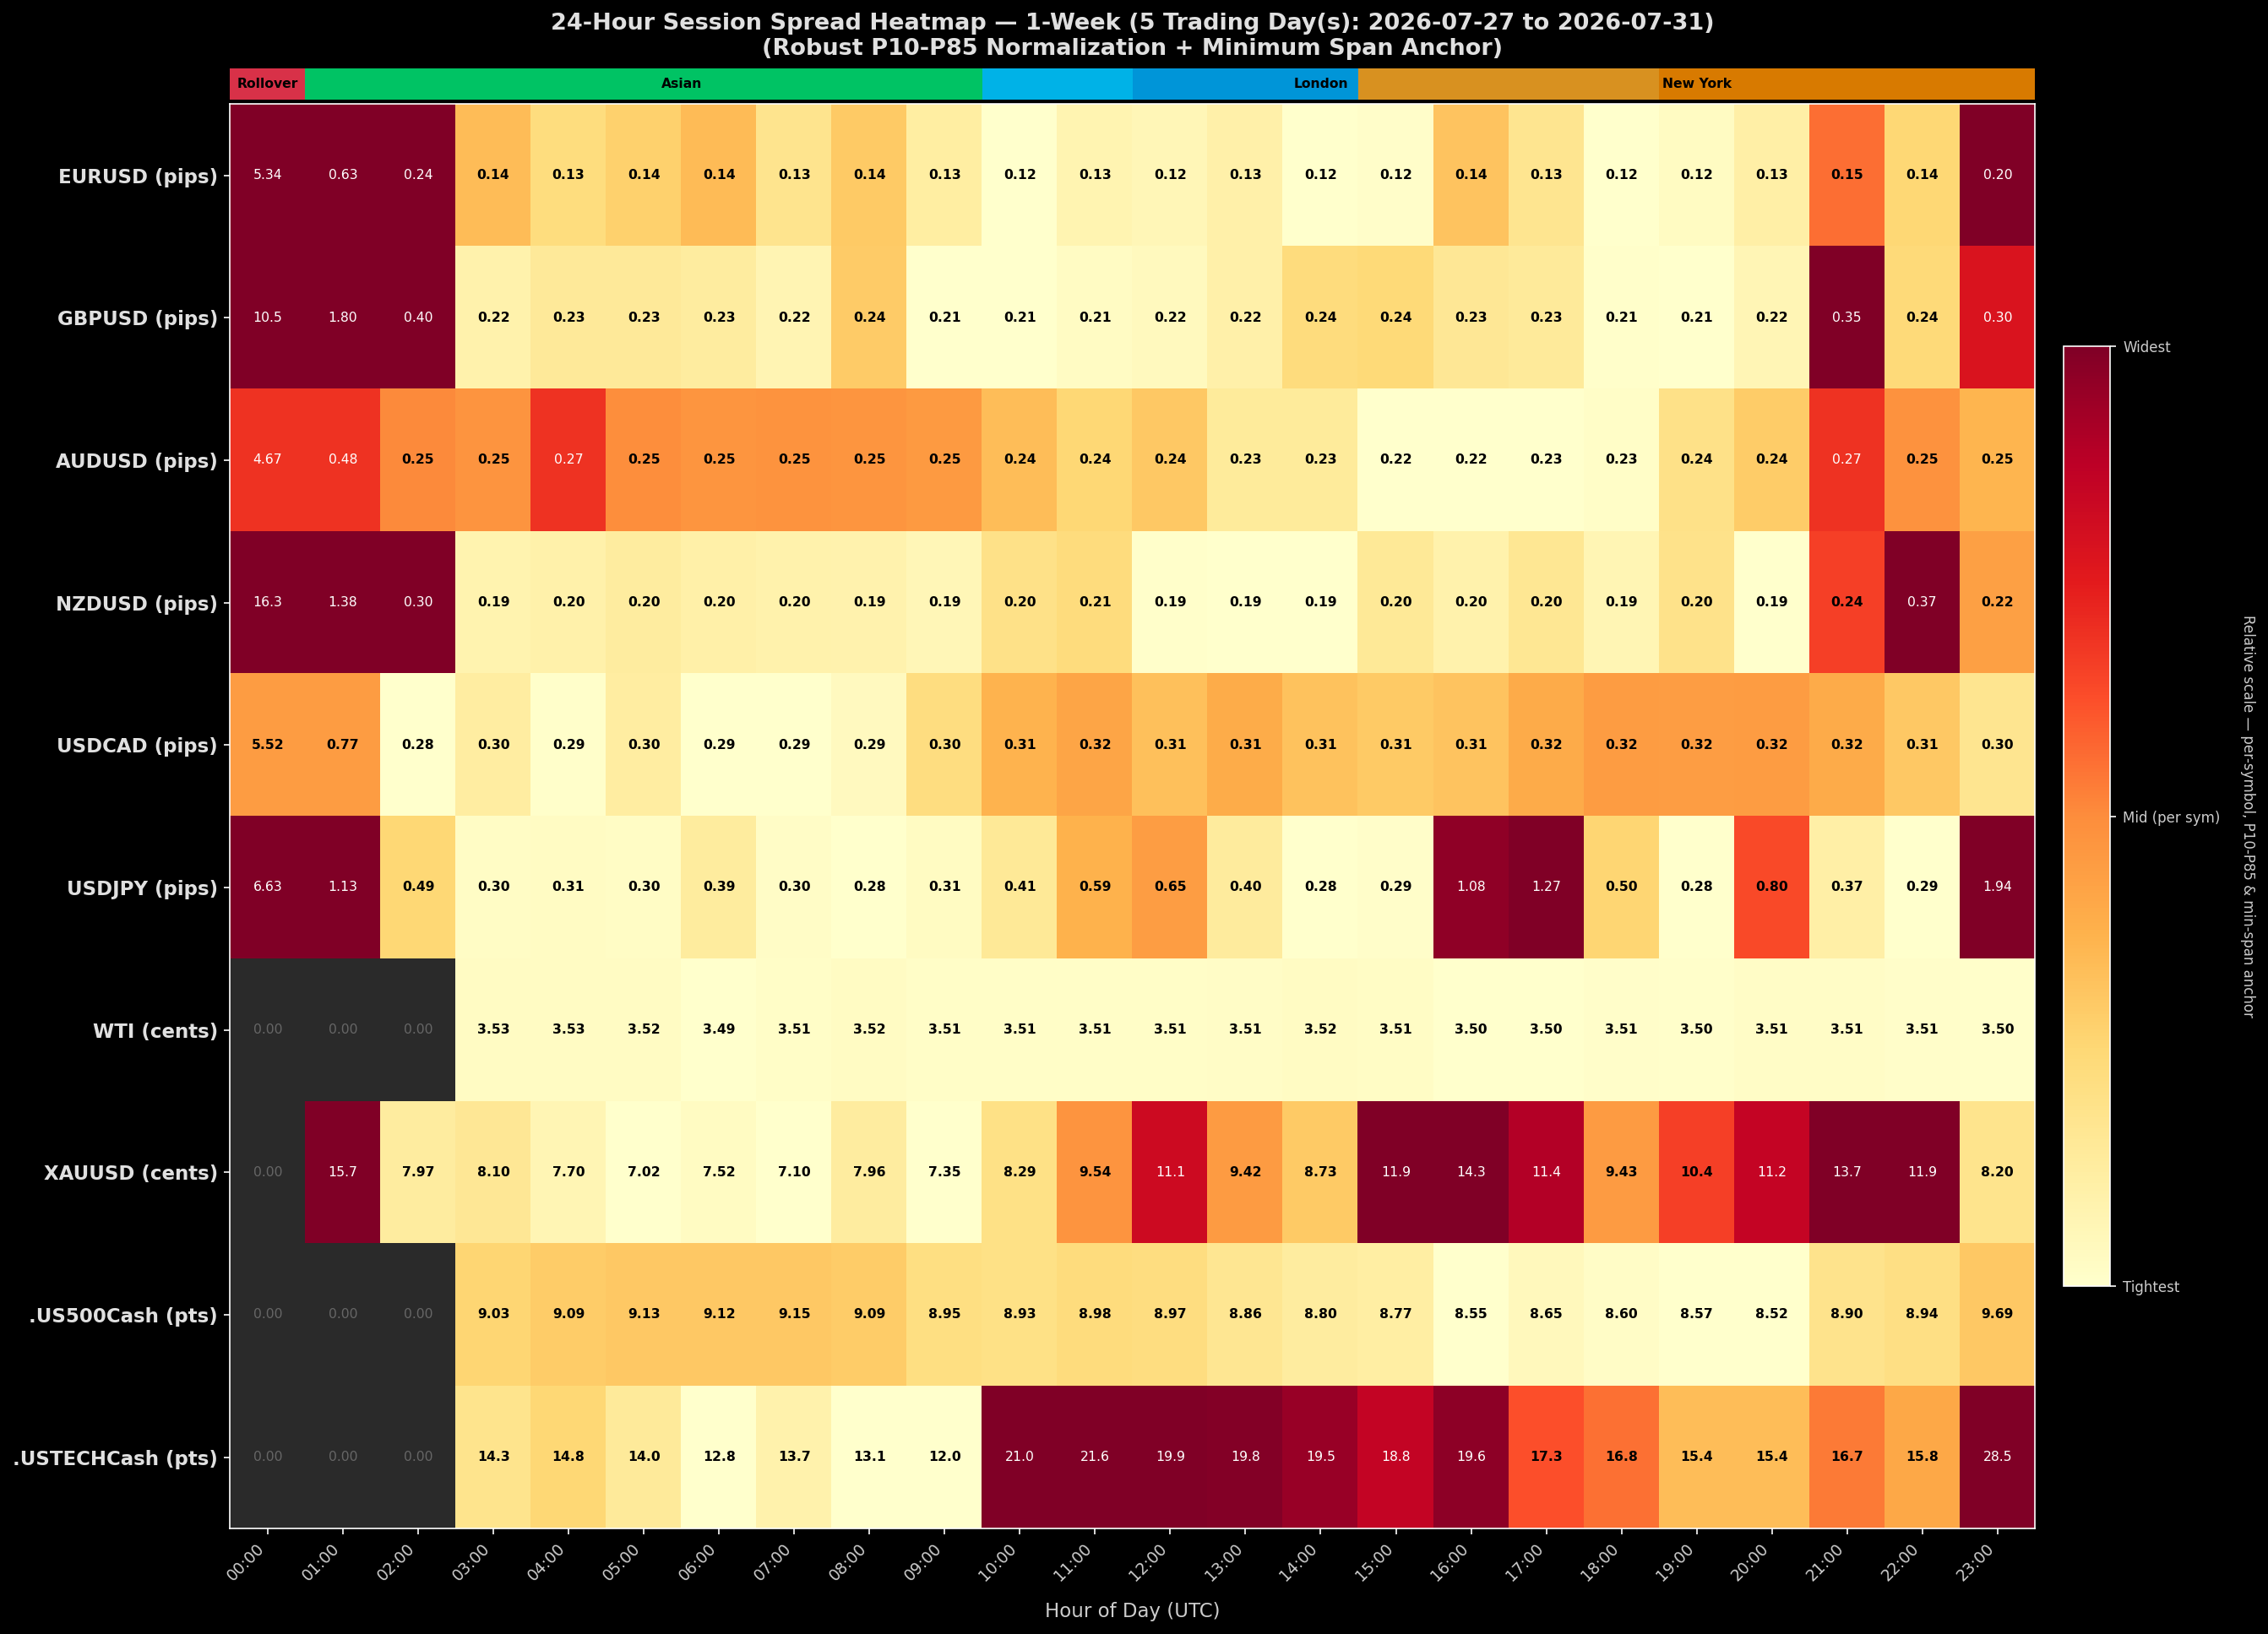

In [90]:
# 1. Cumulative Spread Heatmap
raw_sp  = df_spread.values.T
norm_sp = row_normalize_robust(raw_sp, min_span_pct=0.20)
period_label = f"1-{PERIOD.title()}"
date_range_str = f"{days[0]}" if len(days) == 1 else f"{days[0]} to {days[-1]}"
period_title = f"{period_label} ({len(days)} Trading Day(s): {date_range_str})"

draw_heatmap(
    raw_sp, norm_sp, df_spread.columns, "YlOrRd",
    "Tightest", "Widest",
    f"24-Hour Session Spread Heatmap — {period_title}\n(Robust P10-P85 Normalization + Minimum Span Anchor)",
    lambda x: f"{x:.2f}" if x < 10 else f"{x:.1f}"
)


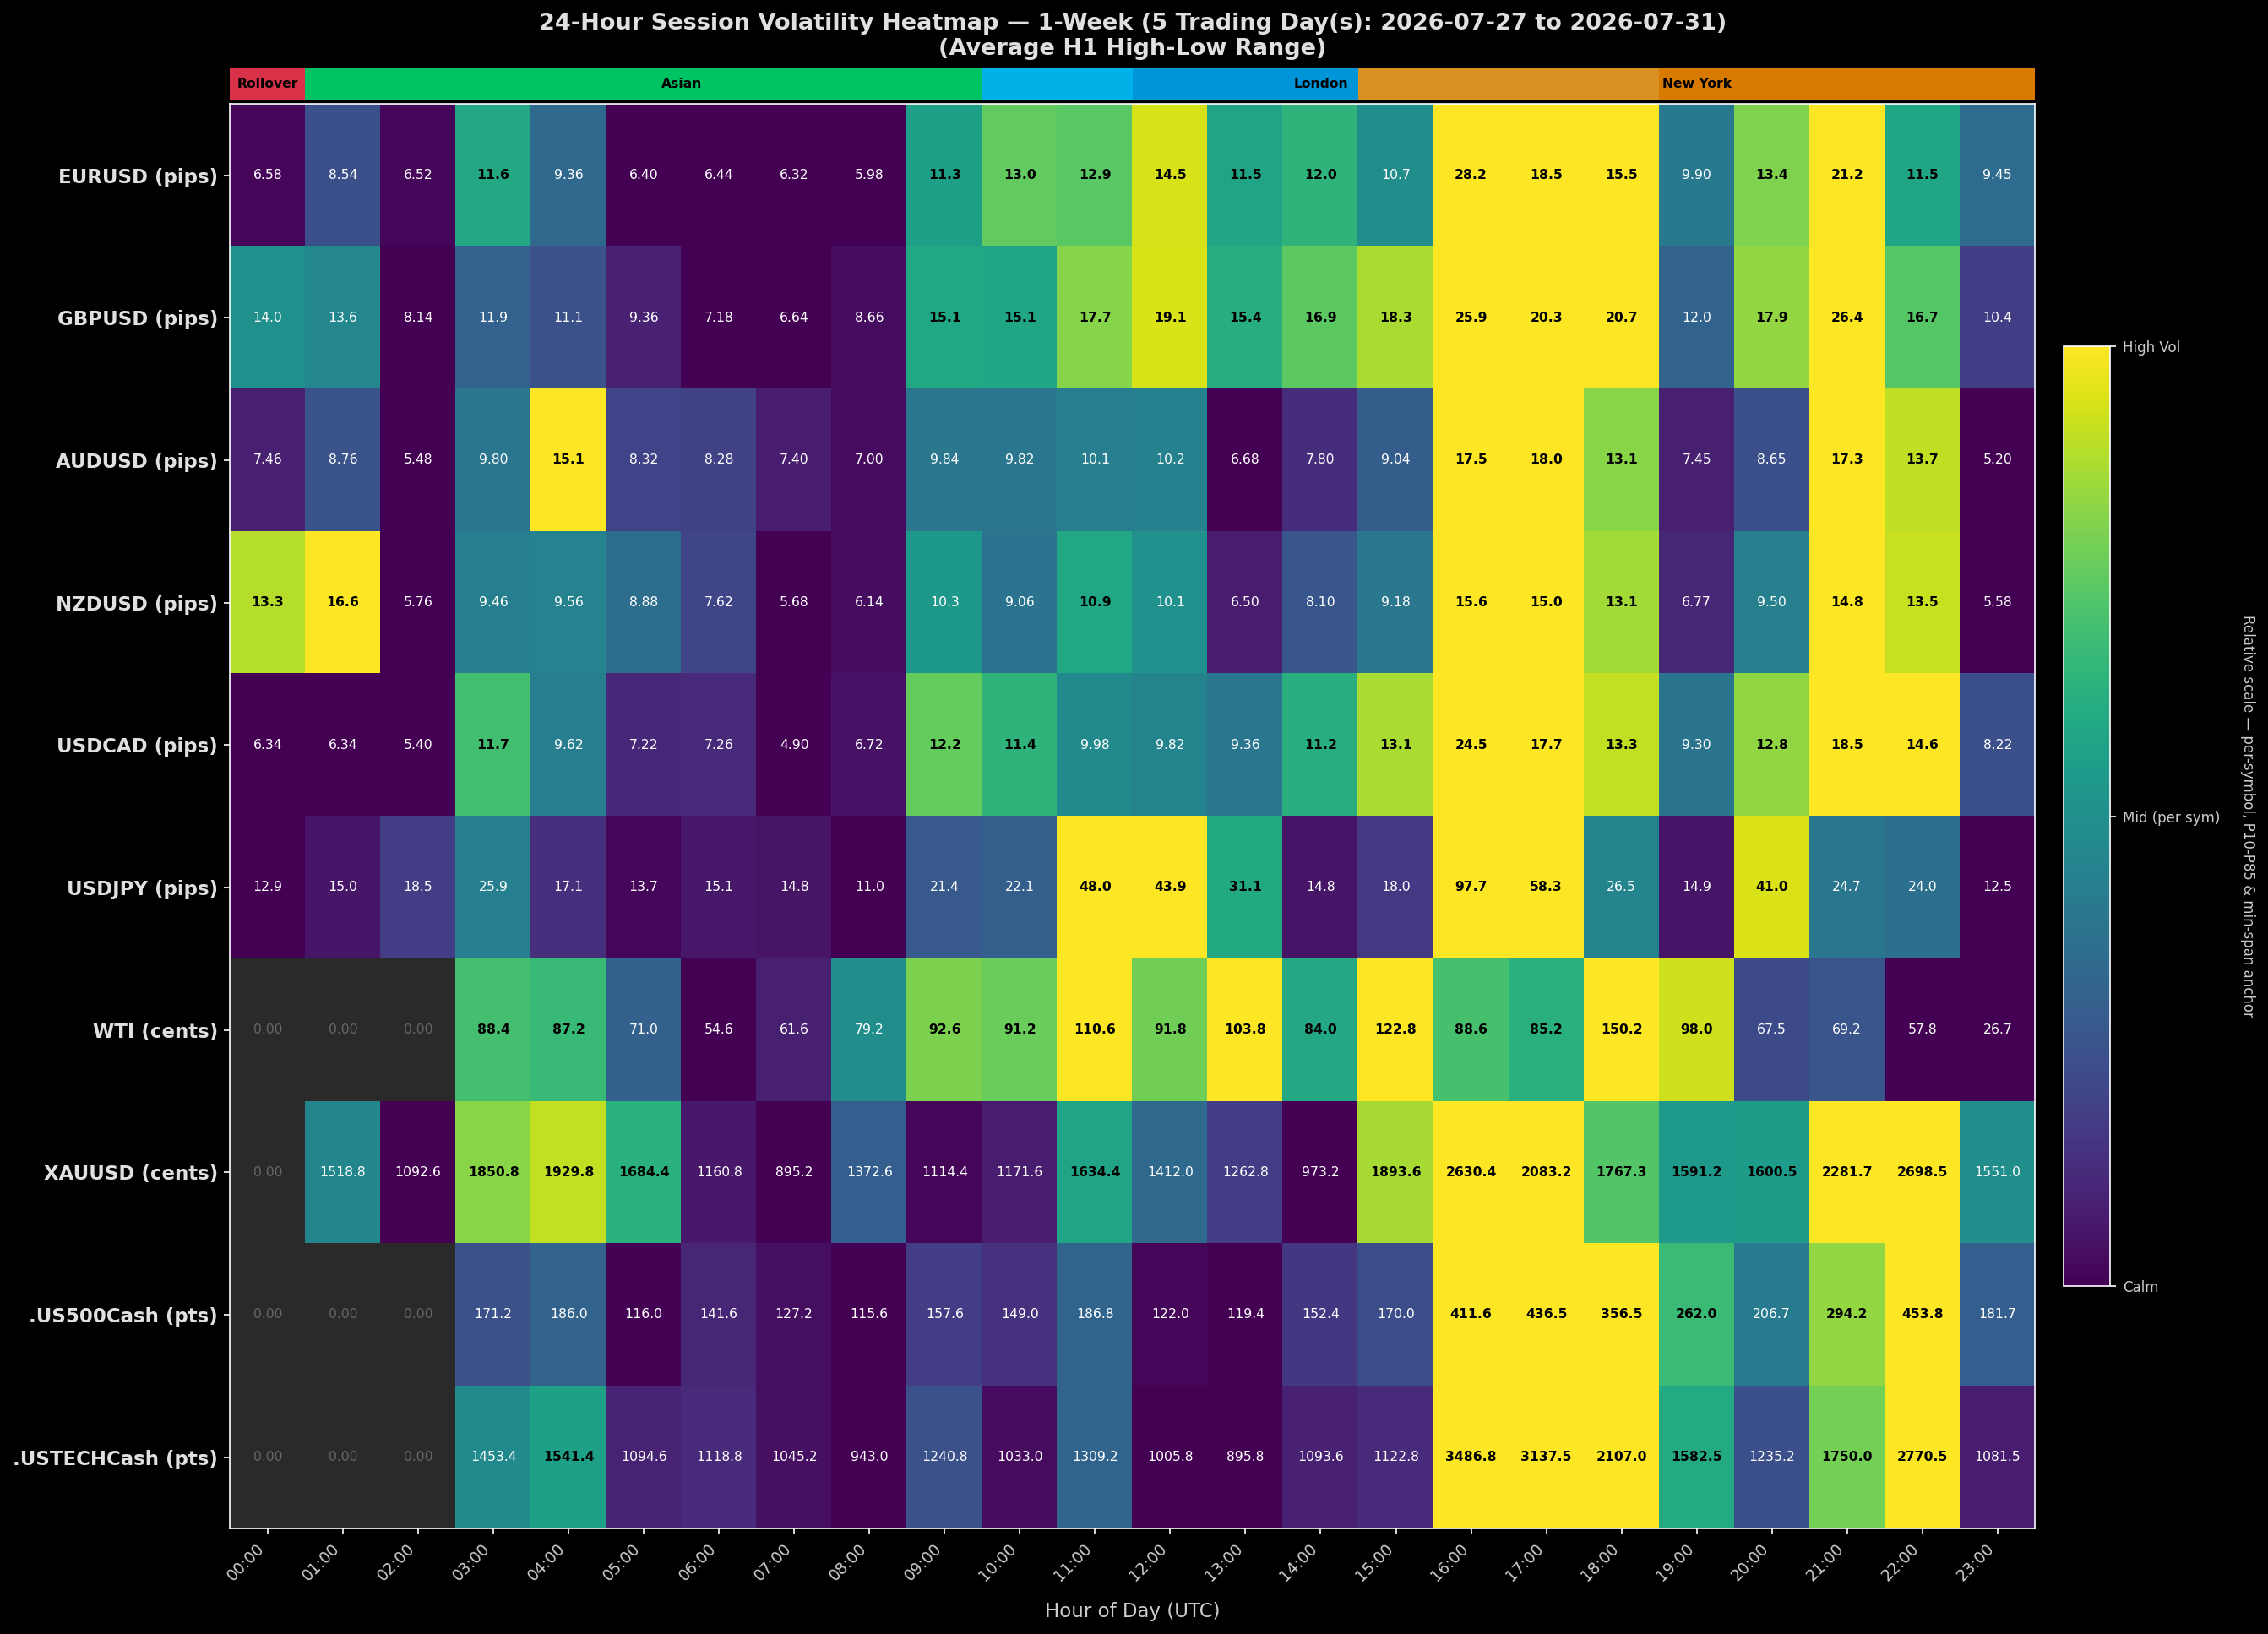

In [91]:
# 2. Cumulative Volatility Heatmap
raw_v  = df_vol.values.T
norm_v = row_normalize_robust(raw_v, min_span_pct=0.20)

draw_heatmap(
    raw_v, norm_v, df_vol.columns, "viridis",
    "Calm", "High Vol",
    f"24-Hour Session Volatility Heatmap — {period_title}\n(Average H1 High-Low Range)",
    lambda x: f"{x:.2f}" if x < 10 else f"{x:.1f}"
)


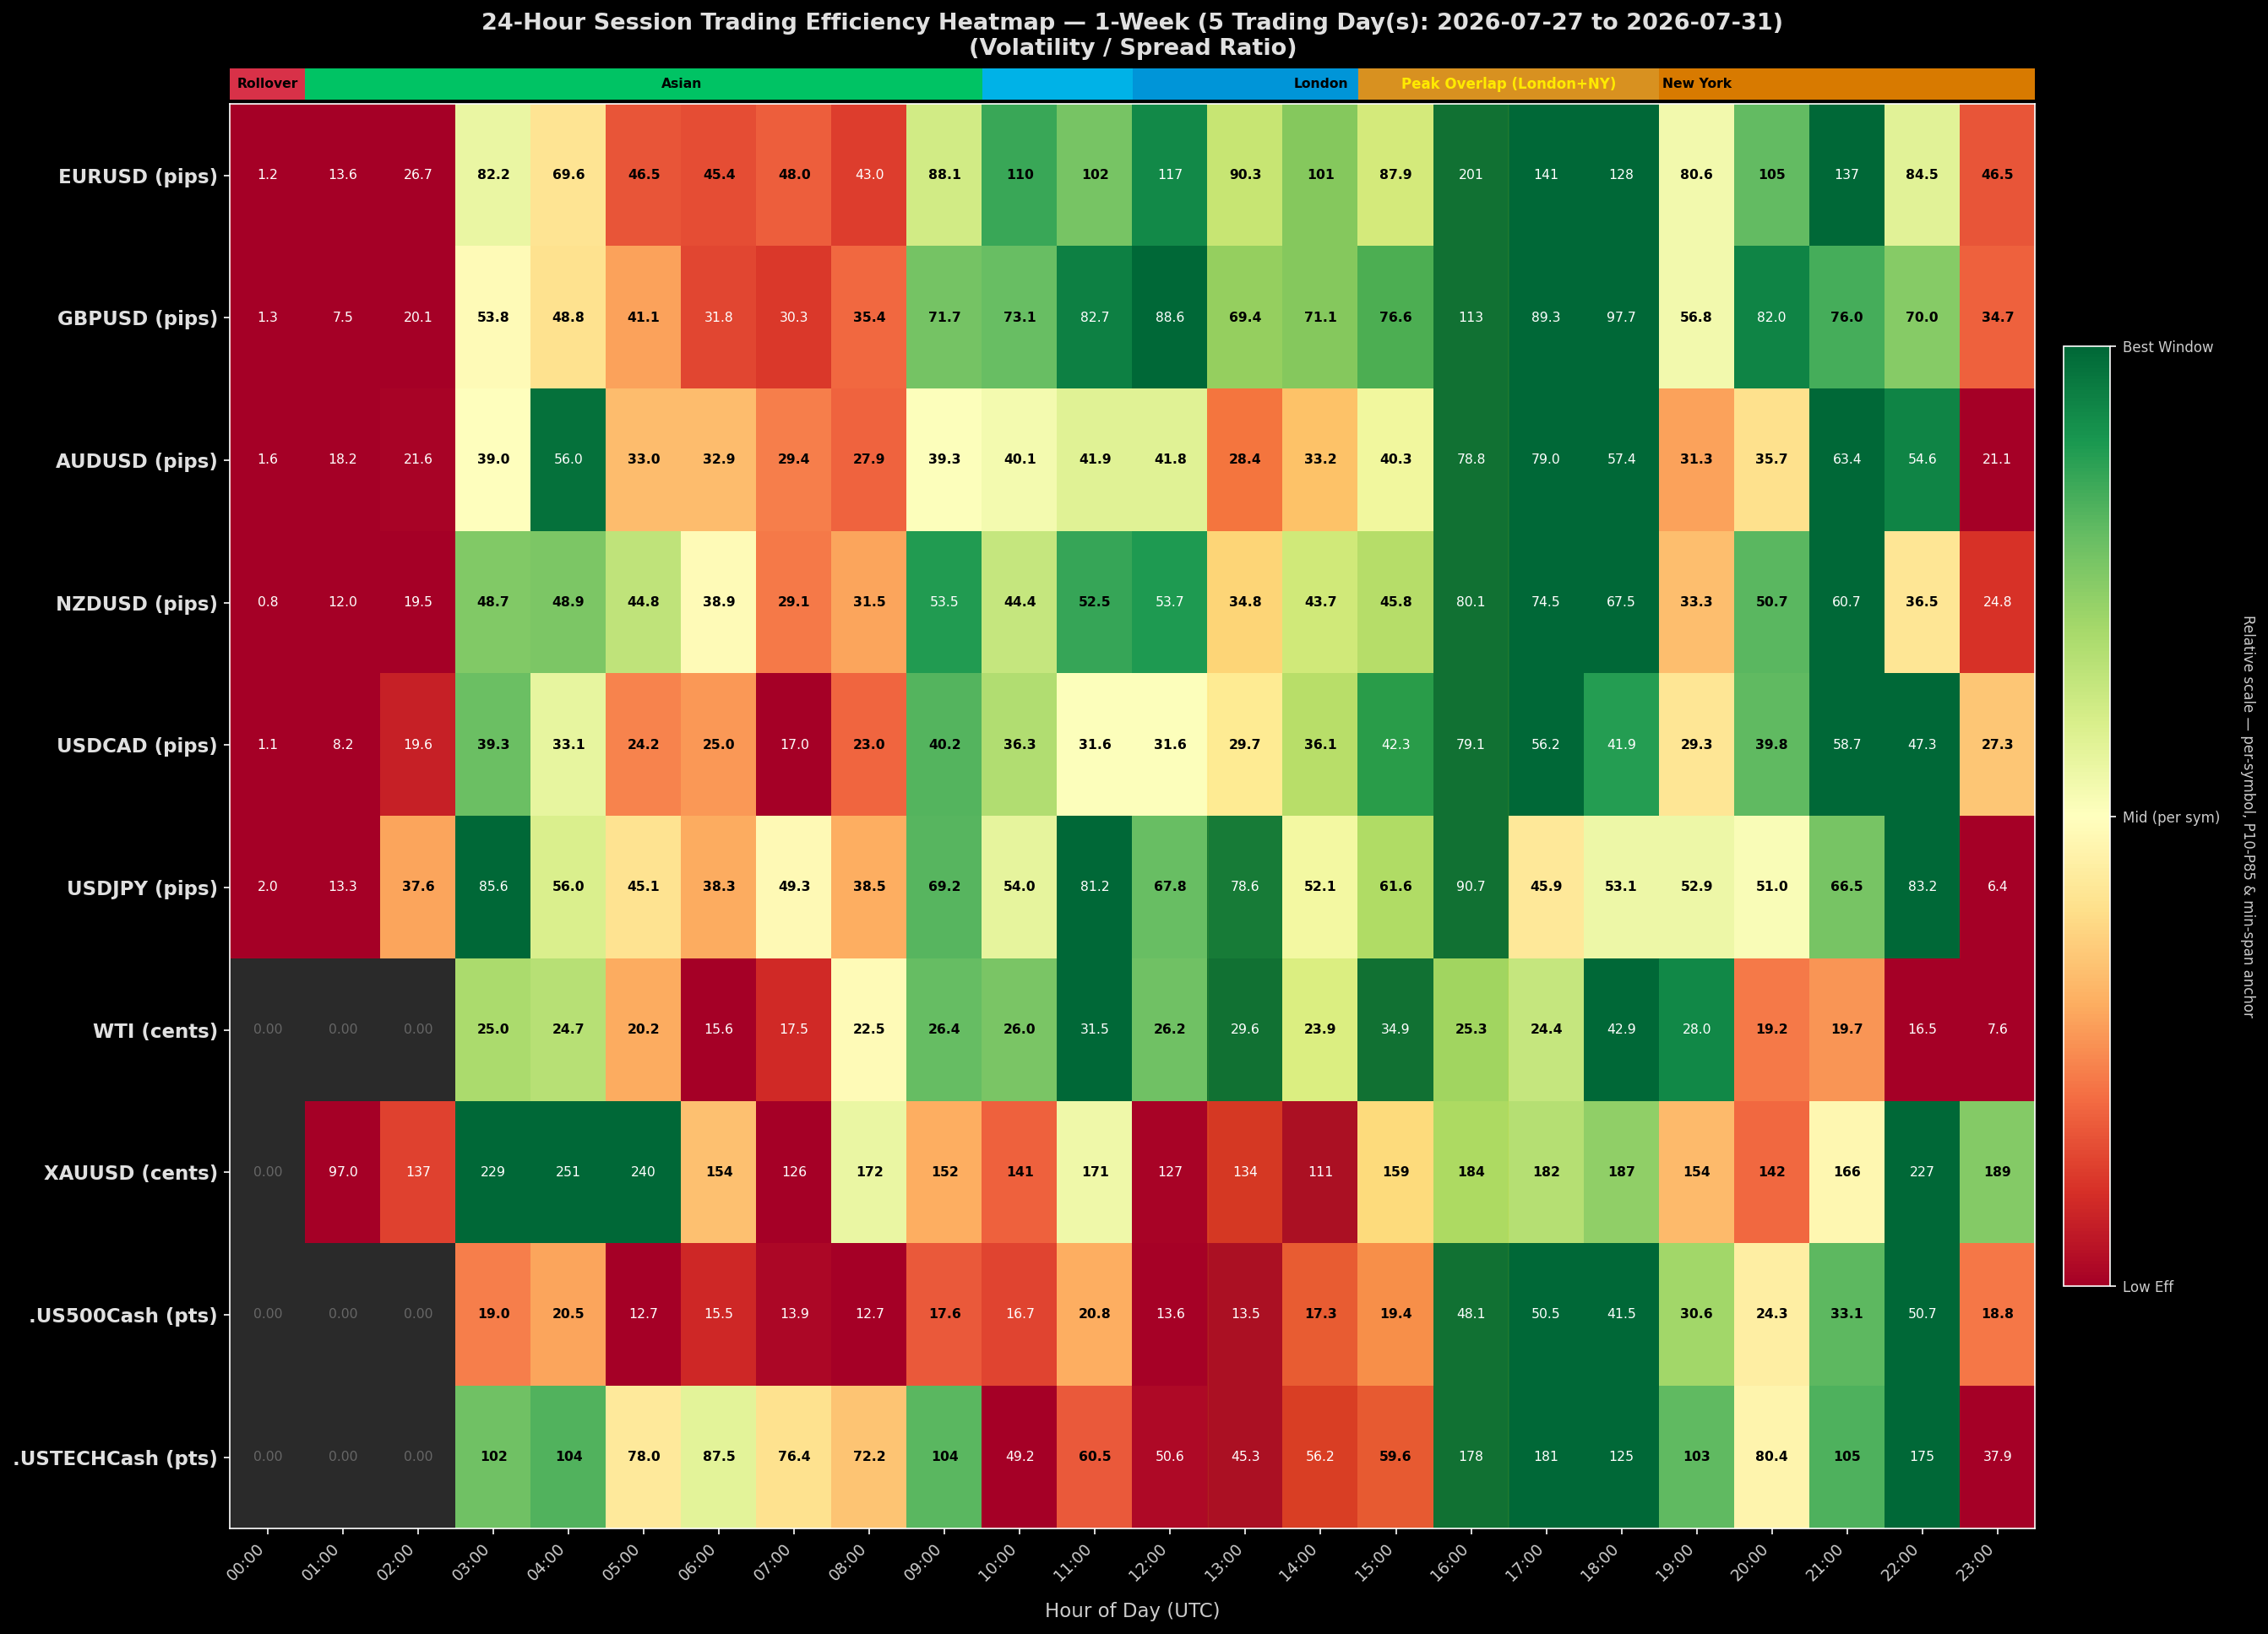

In [92]:
# 3. Cumulative Efficiency Heatmap (Volatility / Spread Ratio)
raw_eff = raw_v / np.maximum(raw_sp, 1e-6)
raw_eff[(raw_sp <= 0) | (raw_v <= 0)] = 0
norm_eff = row_normalize_robust(raw_eff, min_span_pct=0.20)

draw_heatmap(
    raw_eff, norm_eff, df_vol.columns, "RdYlGn",
    "Low Eff", "Best Window",
    f"24-Hour Session Trading Efficiency Heatmap — {period_title}\n(Volatility / Spread Ratio)",
    lambda x: f"{x:.1f}" if x < 100 else f"{x:.0f}",
    overlap=True
)


## Key Trading Insights & Execution Strategy

### 1. Explicit Period Configuration (`PERIODS` Dictionary + `N_TRADING_DAYS = PERIODS[PERIOD]`)
- **`PERIOD = "day"`** ($1$ day): Evaluates the most recent single trading day.
- **`PERIOD = "week"`** ($5$ days): Evaluates the 5-day cumulative average profile.
- **`PERIOD = "month"`** ($20$ days): Evaluates the 20-day cumulative average profile for baseline institutional modeling.

### 2. Minimum Span Anchoring & Visual Accuracy
- **Flat Spread Preservation**: Instruments with near-constant spreads (e.g., WTI ranging 3.49–3.53 cents) render in a uniform light yellow tone instead of falsely saturating from yellow to deep red. This accurately reflects that their spread variation is negligible (~1%).
- **True Volatility Shift Detection**: Instruments with substantial intraday variation (e.g. EURUSD rollover expansion) continue to utilize the full 0.0 to 1.0 color spectrum.

### 3. Peak Efficiency Windows
- **London/New York Peak Overlap (15:00 – 19:00)**: Generates the maximum cumulative trading efficiency across all asset classes. Institutional liquidity keeps spreads tight while news releases and transatlantic order flow push price movement to daily highs.
- **London Morning Session (10:00 – 12:00)**: Strong secondary efficiency peak, particularly for European currency pairs (`EURUSD`, `GBPUSD`) and Crude Oil (`WTI`).

### 4. Low-Efficiency & Execution Risk Windows
- **Rollover Window (00:00 – 02:00)**: Spreads spike dramatically (often 5x to 20x average baseline) due to liquidity provider daily resetting. Automated stop orders and tight market entries should be avoided.
- **Late Asian Session (08:00 – 10:00)**: Market activity drops while spread remains standard, yielding low risk-to-reward for momentum traders.
